# 31 — Scaled Dot-Product Attention

[Notebook 30](./30_attention_intuition_and_weighted_retrieval.ipynb) introduced attention as weighted retrieval with tiny vectors. We now generalize it to batches of query, key, and value sequences, add padding and causal masks, and derive the complete backward pass.

## Learning objectives

- explain why dot-product scores are divided by $\sqrt{D_k}$;
- trace batched query, key, value, score, weight, and output shapes;
- construct broadcastable padding and causal masks;
- implement stable scaled dot-product attention;
- derive gradients through value mixing, softmax, and query-key scores;
- verify query, key, and value gradients numerically.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import (
    eval_numerical_gradient_array,
    relative_error,
)

SEED = 42
generator = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)


## 1. Why scale by $\sqrt{D_k}$?

Assume the coordinates of a query and key are independent, have mean zero, and have variance one. Their dot product is

$$
q\cdot k=\sum_{d=1}^{D_k}q_dk_d.
$$

Under these simplifying assumptions, the sum has variance approximately $D_k$ and standard deviation approximately $\sqrt{D_k}$. Larger key dimensions therefore tend to produce larger-magnitude scores even if the individual coordinates have the same distribution.

Large score differences push softmax toward saturation: one probability approaches one and the others approach zero. Dividing by $\sqrt{D_k}$ keeps the typical score scale closer to one:

$$
S=\frac{QK^T}{\sqrt{D_k}}.
$$

This does not force attention to be uniform. Learned queries and keys can still create strong matches; scaling merely prevents dimension alone from inflating score magnitude.

### Exercise 1 — Observe score growth experimentally


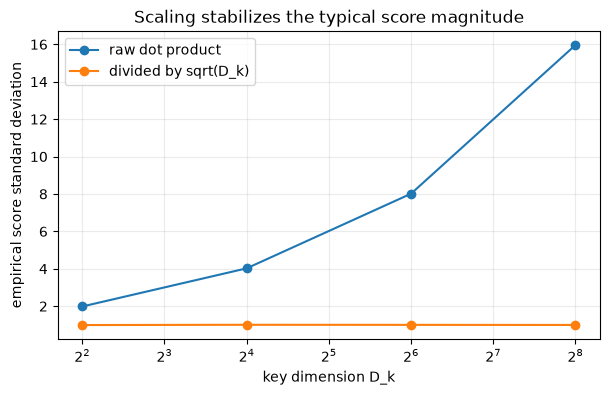

In [3]:
key_dimensions = [4, 16, 64, 256]
num_pairs = 20_000
raw_standard_deviations = []
scaled_standard_deviations = []

for key_dim in key_dimensions:
    queries = generator.normal(size=(num_pairs, key_dim))
    keys = generator.normal(size=(num_pairs, key_dim))

    # The 20,000 rows form 20,000 independent query-key pairs, used to
    # estimate the distribution of one random dot-product score. This is
    # one score per pair—not 20,000 keys attended by each query.
    # Sum along D_k: (num_pairs, D_k) -> (num_pairs,).
    raw_scores = np.sum(queries * keys, axis=1)
    scaled_scores = raw_scores / np.sqrt(key_dim)
    raw_standard_deviations.append(raw_scores.std())
    scaled_standard_deviations.append(scaled_scores.std())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(key_dimensions, raw_standard_deviations, "o-", label="raw dot product")
ax.plot(key_dimensions, scaled_standard_deviations, "o-", label="divided by sqrt(D_k)")
ax.set_xscale("log", base=2)
ax.set_xlabel("key dimension D_k")
ax.set_ylabel("empirical score standard deviation")
ax.set_title("Scaling stabilizes the typical score magnitude")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

np.testing.assert_allclose(
    scaled_standard_deviations, np.ones(len(key_dimensions)), rtol=0.08
)


## 2. Batched attention shapes

Let a batch contain $N$ examples, $L_q$ query positions, $L_k$ stored key/value positions, key dimension $D_k$, and value dimension $D_v$:

```text
Q:        (N, L_q, D_k)
K:        (N, L_k, D_k)
V:        (N, L_k, D_v)
scores:   (N, L_q, L_k)
weights:  (N, L_q, L_k)
output:   (N, L_q, D_v)
```

The query and key lengths may differ, but keys and values must contain the same $L_k$ positions. `np.swapaxes(K, -1, -2)` changes only the last two axes, producing $(N,D_k,L_k)$ for batched multiplication.

### Exercise 2 — Calculate batched scaled scores


In [ ]:
batch_size, query_length, key_length = 2, 3, 4
key_dim, value_dim = 5, 6
query = generator.normal(size=(batch_size, query_length, key_dim))
key = generator.normal(size=(batch_size, key_length, key_dim))
value = generator.normal(size=(batch_size, key_length, value_dim))

# transpose only K's last two axes and calculate scaled scores.
key_transposed = np.swapaxes(key, -1, -2)
scaled_scores = (query @ key_transposed) / np.sqrt(key_dim)

assert key_transposed.shape == (batch_size, key_dim, key_length)
assert scaled_scores.shape == (batch_size, query_length, key_length)
np.testing.assert_allclose(
    scaled_scores[0], query[0] @ key[0].T / np.sqrt(key_dim)
)


## 3. Padding and causal masks

This notebook uses `True` for an allowed query-key pair and `False` for a forbidden pair. A mask must be broadcastable to score shape $(N,L_q,L_k)$.

A padding mask begins with shape $(N,L_k)$ and becomes $(N,1,L_k)$. The singleton query axis means the same unavailable keys are hidden from every query in that example.

For self-attention with $L_q=L_k=L$, a causal mask has shape $(1,L,L)$. Query position $t$ may attend to keys at positions $0$ through $t$, but not to future positions. Combining masks uses element-wise logical AND.

### Exercise 3 — Construct and combine broadcastable masks


In [38]:
test_arr = np.ones((2,3))
(
    test_arr.shape,
    np.expand_dims(test_arr, axis=0).shape,
    np.expand_dims(test_arr, axis=1).shape,
    np.expand_dims(test_arr, axis=2).shape,
)

((2, 3), (1, 2, 3), (2, 1, 3), (2, 3, 1))

In [40]:
test_arr = np.ones((4,4), dtype=int)
test_arr, np.tril(test_arr)

(array([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]]),
 array([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]]))

In [41]:
np.tril(test_arr).shape, np.tril(test_arr)[None, :, :].shape

((4, 4), (1, 4, 4))

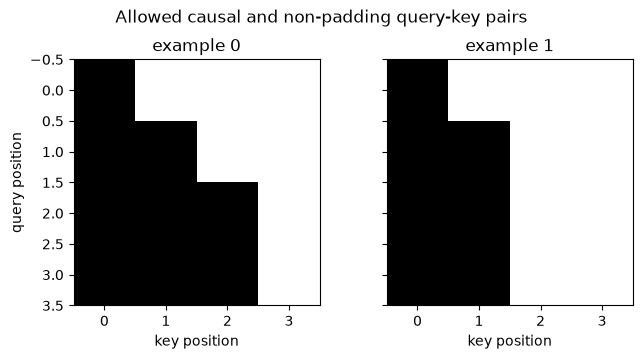

In [42]:
token_is_valid = np.array([
    [True, True, True, False],
    [True, True, False, False],
])
sequence_length = token_is_valid.shape[1]

# Add a singleton query axis: (N, L_k) -> (N, 1, L_k).
padding_mask = np.expand_dims(token_is_valid, axis=1)

# Rows are query positions and columns are key positions. A lower triangle
# allows key j only when j <= query i. Add a singleton batch axis so the
# same causal rule is shared by every example: (L, L) -> (1, L, L).
causal_mask = np.tril(
    np.ones((sequence_length, sequence_length), dtype=bool)
)[None, :, :]

# Boolean AND means a pair is allowed only when the key is both non-padding
# and not in the future. Broadcasting combines (N, 1, L) and (1, L, L)
# into one mask with shape (N, L, L).
combined_mask = padding_mask & causal_mask

assert padding_mask.shape == (2, 1, 4)
assert causal_mask.shape == (1, 4, 4)
assert combined_mask.shape == (2, 4, 4)
assert combined_mask.dtype == np.bool_
np.testing.assert_array_equal(combined_mask[0, 0], [True, False, False, False])
np.testing.assert_array_equal(combined_mask[0, 3], [True, True, True, False])

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharex=True, sharey=True)
for index, axis in enumerate(axes):
    axis.imshow(combined_mask[index], cmap="Greys", vmin=0, vmax=1)
    axis.set_title(f"example {index}")
    axis.set_xlabel("key position")
axes[0].set_ylabel("query position")
fig.suptitle("Allowed causal and non-padding query-key pairs")
plt.tight_layout()
plt.show()


## 4. Scaled dot-product attention forward pass

The complete operation is

$$
S=\frac{QK^T}{\sqrt{D_k}},\qquad
A=\mathrm{softmax}_{keys}(S),\qquad
O=AV.
$$

If a mask is supplied, forbidden scores are replaced with negative infinity before softmax. Every query must have at least one allowed key; otherwise, an entirely masked row has no meaningful probability distribution.

The cache needs $Q$, $K$, $V$, attention weights $A$, the scale, and the broadcast mask for backward propagation.

### Exercise 4 — Implement the batched forward pass


In [46]:
def scaled_dot_product_attention_forward(query, key, value, mask=None):
    """Return batched attention output, weights, and backward cache."""
    # calculate scaled scores.
    key_dim = key.shape[-1]
    key_transposed = np.swapaxes(key, -1, -2)
    scale = np.sqrt(key_dim)
    scaled_scores = (query @ key_transposed) / scale

    # apply mask before exponentional and probability calculation
    broadcast_mask = None
    if mask is not None:
        broadcast_mask = np.broadcast_to(
            np.asarray(mask, dtype=bool),
            scaled_scores.shape,
        )

        if not np.all(np.any(broadcast_mask, axis=-1)):
            raise ValueError(
                "every query must have at least one allowed key"
            )

        scaled_scores = np.where(
            broadcast_mask,
            scaled_scores,
            -np.inf,
        )

    # softmax attention weights calculation
    shifted_scores = scaled_scores - scaled_scores.max(axis=-1, keepdims=True)
    exp_scores = np.exp(shifted_scores)
    attention_weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)

    # output 
    output = attention_weights @ value

    # cache
    # Save the mask after broadcasting so backward sees exactly the same
    # allowed query-key pairs as the score tensor.
    cache = (query, key, value, attention_weights, scale, broadcast_mask)

    return output, attention_weights, cache


attention_output, attention_weights, attention_cache = (
    scaled_dot_product_attention_forward(query, key, value)
)
assert attention_output.shape == (batch_size, query_length, value_dim)
assert attention_weights.shape == (batch_size, query_length, key_length)
np.testing.assert_allclose(attention_weights.sum(axis=-1), 1.0)

self_query = generator.normal(size=(2, 4, key_dim))
self_value = generator.normal(size=(2, 4, value_dim))
masked_output, masked_weights, masked_cache = scaled_dot_product_attention_forward(
    self_query, self_query, self_value, combined_mask
)
assert masked_output.shape == (2, 4, value_dim)
np.testing.assert_array_equal(masked_weights[~combined_mask], 0.0)
np.testing.assert_allclose(masked_weights.sum(axis=-1), 1.0)


## 5. Backward pass, one operation at a time

Let `dout` have the same shape as $O$. Reverse the forward operations.

### Weighted value mixture

For $O=AV$:

$$
dA=dO V^T,\qquad dV=A^T dO.
$$

These are batched matrix multiplications over the final two axes.

### Row-wise softmax

Earlier notebooks usually combined softmax directly with cross-entropy, where the score gradient simplifies to `probabilities - one_hot(target)`. Attention uses softmax as an intermediate operation, and its upstream gradient $dA$ comes from $O=AV$, so we need the general softmax backward rule.

Consider one query row with scores $S_1,\ldots,S_M$ and weights $A_1,\ldots,A_M$. Index $j$ identifies one input score, while index $i$ identifies one softmax output weight. The expression

$$
\frac{\partial A_i}{\partial S_j}
$$

is a **local softmax derivative**: it asks how weight $A_i$ changes when score $S_j$ changes. It is not yet $dS_j$, which means the final loss gradient $\partial L/\partial S_j$.

For one row, $A_i=e^{S_i}/\sum_k e^{S_k}$. All weights share the same denominator, so changing $S_j$ affects every $A_i$. The derivative can be written compactly as

$$
\frac{\partial A_i}{\partial S_j}=A_i(\delta_{ij}-A_j).
$$

Here $\delta_{ij}$ is the Kronecker delta: it equals $1$ when $i=j$ and $0$ otherwise. Therefore:

- for the matching weight, $\partial A_i/\partial S_i=A_i(1-A_i)$;
- for every other weight, $\partial A_i/\partial S_j=-A_iA_j$.

Increasing one score raises its own weight but lowers the others because the row must continue to sum to one.

Now define the upstream and result gradients:

$$
dA_i=\frac{\partial L}{\partial A_i},\qquad
dS_j=\frac{\partial L}{\partial S_j}.
$$

One score $S_j$ affects the loss through every weight $A_i$, so the multivariable chain rule adds all of those paths:

$$
dS_j=\sum_i
\frac{\partial L}{\partial A_i}
\frac{\partial A_i}{\partial S_j}
=\sum_i dA_iA_i(\delta_{ij}-A_j).
$$

The delta keeps only the $i=j$ term in the first part of the sum. Since $A_j$ does not depend on the summation index $i$, it can be factored out of the second part:

$$
dS_j=dA_jA_j-A_j\sum_i dA_iA_i
=A_j\left(dA_j-\sum_i dA_iA_i\right).
$$

Therefore, the efficient vector form is

$$
dS=A\odot\left(dA-\sum_i dA_iA_i\right).
$$

In NumPy, the sum is taken over the key axis with `axis=-1, keepdims=True`, producing one scalar per query row that broadcasts back across its keys. Masked positions must have zero score gradient.

### Scaled query-key scores

For $S=QK^T/\sqrt{D_k}$:

$$
dQ=\frac{dS K}{\sqrt{D_k}},\qquad
dK=\frac{dS^T Q}{\sqrt{D_k}}.
$$

### Exercise 5 — Implement attention backward


In [48]:
def scaled_dot_product_attention_backward(dout, cache):
    """Return gradients with respect to query, key, and value."""
    query, key, value, attention_weights, scale, mask = cache

    # O = A @ V. Swap only the final two matrix axes, leaving the batch
    # axis in place.
    dA = dout @ np.swapaxes(value, -1, -2)
    dV = np.swapaxes(attention_weights, -1, -2) @ dout

    # General row-wise softmax backward. The inner sum is one scalar for
    # each query row: sum_j(dA_j * A_j).
    softmax_correction = np.sum(
        dA * attention_weights, axis=-1, keepdims=True
    )
    dS = attention_weights * (dA - softmax_correction)

    # A forbidden score was replaced by a constant (-infinity) during the
    # forward pass, so no gradient should flow through that score. The
    # attention weight is already zero there, but applying the mask makes
    # this rule explicit and protects against numerical residue.
    if mask is not None:
        dS = np.where(mask, dS, 0.0)

    # S = Q @ K.T / scale. Again, swap only the matrix axes.
    dQ = (dS @ key) / scale
    dK = (np.swapaxes(dS, -1, -2) @ query) / scale

    return dQ, dK, dV


dout = generator.normal(size=attention_output.shape)
dquery, dkey, dvalue = scaled_dot_product_attention_backward(
    dout, attention_cache
)
assert dquery.shape == query.shape
assert dkey.shape == key.shape
assert dvalue.shape == value.shape


## 6. Numerical gradient check

Attention is a composition of matrix multiplication, softmax, and another matrix multiplication. Numerical checking verifies that all gradient paths—including the fact that keys affect the score matrix while values affect the mixture—were routed correctly.

### Exercise 6 — Check all three input gradients


In [49]:
numerical_dquery = eval_numerical_gradient_array(
    lambda candidate: scaled_dot_product_attention_forward(
        candidate, key, value
    )[0],
    query,
    dout,
)
numerical_dkey = eval_numerical_gradient_array(
    lambda candidate: scaled_dot_product_attention_forward(
        query, candidate, value
    )[0],
    key,
    dout,
)
numerical_dvalue = eval_numerical_gradient_array(
    lambda candidate: scaled_dot_product_attention_forward(
        query, key, candidate
    )[0],
    value,
    dout,
)

attention_errors = {
    "dquery": relative_error(dquery, numerical_dquery),
    "dkey": relative_error(dkey, numerical_dkey),
    "dvalue": relative_error(dvalue, numerical_dvalue),
}
print(attention_errors)
assert all(error < 1e-8 for error in attention_errors.values())


{'dquery': 1.533490023513411e-09, 'dkey': 3.800467566206291e-10, 'dvalue': 1.4161543491776812e-10}


## 7. Reflection

1. Why does the typical unscaled dot-product magnitude grow with $D_k$?
2. What problem can excessively large score magnitudes cause for softmax?
3. What does entry `scores[n, i, j]` represent?
4. Why may $L_q$ differ from $L_k$, while keys and values must share $L_k$?
5. Why does a padding mask have a singleton query axis?
6. What information does a causal mask prevent from being used?
7. Why is the softmax backward expression not simply `dscore = dweight`?
8. Through which operation does the value gradient arise, and through which operation do query and key gradients arise?

### Answers

1. A dot product sums $D_k$ coordinate products. Under the simplifying independent, zero-mean, unit-variance assumption, its variance grows like $D_k$ and its typical magnitude grows like $\sqrt{D_k}$; the signed mean still remains near zero.
2. Large score differences can saturate softmax, producing probabilities very close to $1$ and $0$ and correspondingly small gradients through most positions.
3. It is the scaled similarity score between query position $i$ and key position $j$ in batch example $n$.
4. A model may retrieve from a stored sequence whose length differs from the number of queries, so $L_q$ and $L_k$ may differ. Keys and values must share $L_k$ because every key identifies the corresponding value that will be retrieved.
5. Padding describes which **keys** are real for one example. The singleton query axis lets that same key-validity row broadcast across every query in the example.
6. It prevents query position $i$ from using keys at future positions $j>i$, which would leak unavailable future information during autoregressive prediction.
7. Softmax is not element-wise: changing one score changes every weight in that row through their shared denominator. Backward must combine the upstream $dA$ with the complete local softmax derivative.
8. $dV$ arises through the weighted mixture $O=AV$. The query and key gradients arise through the scaled score operation $S=QK^T/\sqrt{D_k}$ after backpropagating through softmax.
